## **Learning Curve**

A **Learning Curve** is a plot that shows the relationship between the number of training samples used to train a model and the model's performance (error or accuracy).

### 1. Purpose
Learning curves are used to diagnose two fundamental problems in machine learning:
*   **High Bias (Underfitting):** The model is too simple to capture the underlying patterns. The training error and validation error are both high and very close to each other.
*   **High Variance (Overfitting):** The model is too complex and memorizes noise. There is a large gap between the training error (very low) and the validation error (very high).

### 2. How to Interpret the Plot

| Scenario | Training Error | Validation Error | Diagnosis | Solution |
| :--- | :--- | :--- | :--- | :--- |
| **High Bias** | High | High (Close to training) | **Underfitting** | Increase model complexity, add features, or reduce regularization. |
| **High Variance** | Low | High (Large gap) | **Overfitting** | Get more data, reduce complexity, or increase regularization. |
| **Ideal** | Low | Low (Small gap) | **Good Fit** | The model has generalized well. |

### 3. Implementation with Scikit-Learn
The `learning_curve` function automates the process of training the model repeatedly with increasing training set sizes.

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Load data
X, y = load_iris(return_X_y=True)

# Define model
model = RandomForestClassifier(n_estimators=10, max_depth=5)

# Calculate learning curve
# train_sizes: the number of training examples to use
# train_score: accuracy on the training set
# test_score: accuracy on the validation set
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate means and standard deviations for plotting
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting
plt.plot(train_sizes, train_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")
plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()
```

### 4. Practical Decision Matrix

| If you see... | It means... | Action |
| :--- | :--- | :--- |
| **Curves converge at high error** | Model is too simple (High Bias) | Use a more complex model (e.g., move from Linear Regression to Random Forest). |
| **Large gap between curves** | Model is overfitting (High Variance) | Add more training data or use regularization (L1/L2). |
| **Curves converge at low error** | Model is performing well | You have reached the optimal model for this dataset. |

## Example:

#### **LogisticRegression:**

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import learning_curve, LearningCurveDisplay, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

In [77]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [78]:
pipe = make_pipeline(StandardScaler(),
                    LogisticRegression(
                                        random_state=42,
                                        solver='lbfgs',
                                        max_iter=10000))

In [79]:
train_sizes, train_score, test_score = learning_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1, 10),
    cv = 10, # each train size would run 10-fold cross-validation
    scoring='accuracy',
    random_state=42
)

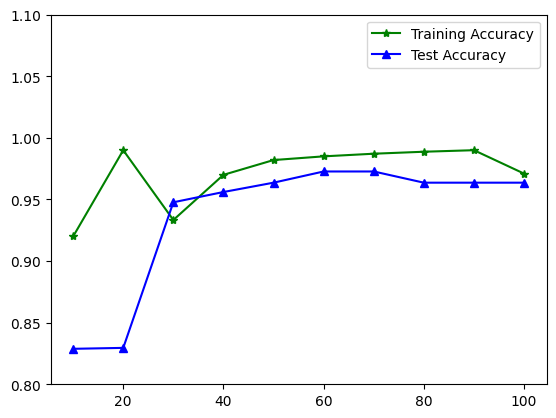

In [80]:
avg_train_score = train_score.mean(axis=1)
avg_train_std = train_score.std(axis=1)
avg_test_score = test_score.mean(axis=1)
avg_test_std = test_score.std(axis=1)


plt.plot(train_sizes, avg_train_score, marker='*', color='g', label='Training Accuracy')
plt.plot(train_sizes, avg_test_score, marker='^', color='b', label='Test Accuracy')

plt.ylim([0.8, 1.1])
plt.legend()
plt.show()

#### **RandomForestClassifier:**

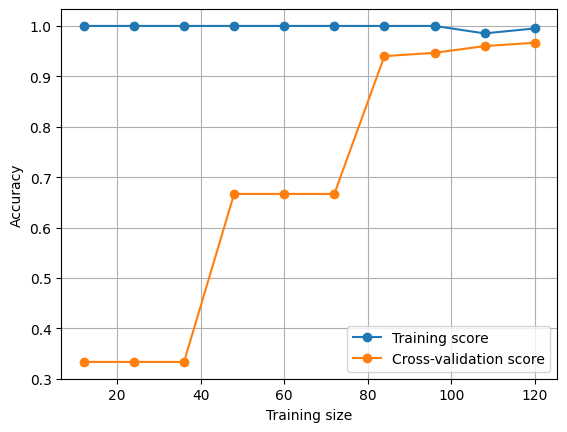

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Load data
X, y = load_iris(return_X_y=True)

# Define model
model = RandomForestClassifier(n_estimators=10, max_depth=5)

# Calculate learning curve
# train_sizes: the number of training examples to use
# train_score: accuracy on the training set
# test_score: accuracy on the validation set
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate means and standard deviations for plotting
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting
plt.plot(train_sizes, train_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")
plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

#### **LearningCurveDisplay:**

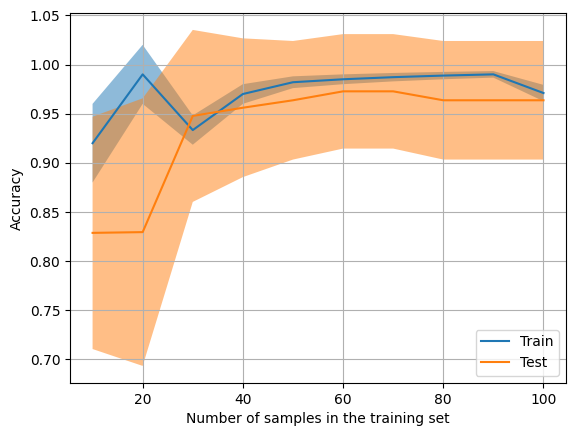

In [83]:
LearningCurveDisplay.from_estimator(
    pipe,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1,1,10),
    cv=10,
    n_jobs=-1,
    scoring='accuracy'
)
plt.grid()
plt.show()

### **cv = 10:**

In the context of `learning_curve`, `cv=10` refers to **K-Fold Cross-Validation**.

Specifically, it means that for **every single training size** specified in your `train_sizes` array, the function performs a 10-fold cross-validation.

#### How it works step-by-step:

1.  **The Loop:** The function iterates through your 10 training sizes (10%, 20%, ..., 100%).
2.  **The Split (K-Fold):** For a specific training size (e.g., 50% of your data), the function:
    *   Takes that 50% subset of data.
    *   Splits that subset into **10 equal parts** (folds).
    *   Runs **10 separate training iterations**. In each iteration, it uses 9 parts for training and 1 part for validation.
3.  **The Averaging:** After running those 10 iterations, it calculates the **mean** and **standard deviation** of the scores.
4.  **The Output:** The `train_score` and `test_score` arrays you receive contain these **averaged** values.

#### Why `cv=10` is important here:
*   **Reducing Noise:** Because machine learning models are sensitive to how data is split, a single training/validation split might give you a "lucky" or "unlucky" score. By running 10 folds, you get a much more stable and reliable estimate of how the model performs at that specific training size.
*   **Computational Cost:** This is why `learning_curve` can be slow. In your specific code, the total number of model fits is:
    $$\text{Number of train\_sizes} \times \text{cv} = 10 \times 10 = \mathbf{100 \text{ fits}}$$

#### Summary of your parameters:
*   `train_sizes`: Defines the "X-axis" (how much data we give the model).
*   `cv=10`: Defines the "Reliability" (how many times we repeat the experiment at each X-point to get an average).
*   `scoring='accuracy'`: Defines the "Y-axis" (what metric we are measuring).